# How well do jobs and skills pay for Data roles?

In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast as ast
import seaborn as sns

from datasets import load_dataset

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#filtering for jobs in USA:
df_US = df[df['job_country'] == 'United States'].copy()

In [13]:
df_US = df_US.dropna(subset=['salary_year_avg'])
job_titles = df_US['job_title_short'].value_counts().index[:6].to_list()

df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]
#df_US_top6.head(10)

In [17]:
#sorting jobs based on their median salary in order to plot them in that order
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

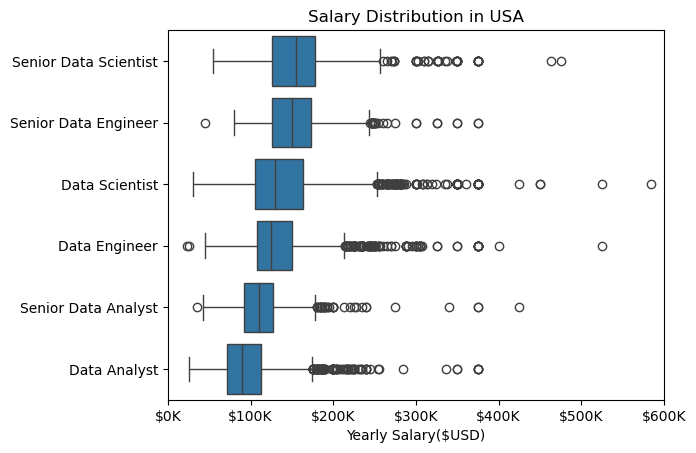

In [18]:
#plotting using seaborn
sns.boxplot(df_US_top6, x='salary_year_avg', y='job_title_short', order=job_order)
plt.title('Salary Distribution in USA')
plt.xlabel('Yearly Salary($USD)')
plt.ylabel('')

ticks_x = plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0,600000)
plt.show()

# Investigae Median Salary vs Skill for Data Analysts

In [33]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False).head(10)
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).head(10)
df_DA_skills = df_DA_skills.sort_values(by='median', ascending=False)

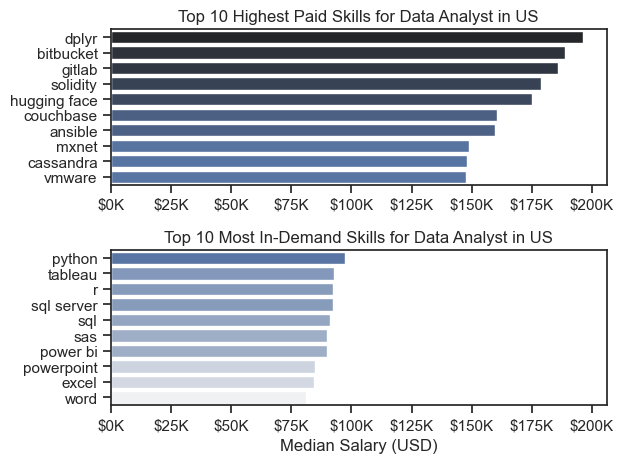

In [34]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r') #it's saying apply the hue based on median value' palette='_r': reverse the palette
ax[0].legend().remove()
#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) #another way to reverse
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst in US')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter (lambda x, _:f'${int(x/1000)}K'))

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
#df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].legend().remove()
ax[1].set_xlim(ax[0].get_xlim()) #setting the same x-axis limit as the 1st one
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst in US')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter (lambda x, _:f'${int(x/1000)}K'))
ax[1].set_ylabel('')

fig.tight_layout()
plt.show()